# Giai đoạn 6 — Phân tích chi phí lỗi bất đối xứng (bản hoàn thiện)

Accuracy gây hiểu lầm nguy hiểm trong rà phá mìn vì hai kiểu sai không ngang nhau:

| Kiểu sai | Hậu quả |
|---|---|
| Báo "không mìn" mà thực ra **có** (False Negative) | **Người đào có thể chết** |
| Báo "có mìn" mà thực ra **không** (False Positive) | Chỉ tốn công đào một hố trống |

Giai đoạn này thay accuracy bằng các thước đo phản ánh đúng an toàn.

> **Sửa lỗi phương pháp quan trọng so với bản trước.** Chọn ngưỡng quyết định để đạt recall=100% *trên chính tập test* rồi báo cáo trên tập test đó **chính là rò rỉ** — đúng lỗi cả đồ án đang phê phán. Bản này **chọn ngưỡng trên validation, đánh giá trên test tách biệt**, và lặp qua CV. Nhờ đó phát hiện được thông điệp an toàn thật: *một ngưỡng đạt 100% recall trên validation thường KHÔNG giữ được 100% trên dữ liệu mới* — tức không thể đảm bảo tuyệt đối không bỏ sót chỉ bằng một ngưỡng cố định.

## 1. Chuẩn bị — bài toán PHÁT HIỆN (nhị phân)

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (precision_recall_curve, confusion_matrix,
                             average_precision_score, roc_auc_score)
import os

RANDOM_STATE = 42
os.makedirs("../result/figures", exist_ok=True)

try:
    df = pd.read_excel("../Data/Mine_Dataset_main.xls", engine="xlrd")
except Exception:
    df = pd.read_excel("../Data/Mine_Dataset_main.xls")
df.columns = [str(c).strip() for c in df.columns]
if list(df.columns[:4]) != ["V","H","S","M"]:
    df = df.rename(columns=dict(zip(df.columns[:4], ["V","H","S","M"])))
df["M"] = df["M"].astype(int)
X = df[["V","H","S"]].values.astype(float)
y = (df["M"] != 1).astype(int).values      # 1 = có mìn, 0 = không mìn
print("Tổng:", len(y), "| có mìn:", int(y.sum()), "| không mìn:", int((y==0).sum()))

# Mô hình đại diện: gradient boosting (khuyến nghị từ GĐ4). Có thể thay CatBoost/LightGBM.
def make_model():
    return HistGradientBoostingClassifier(random_state=RANDOM_STATE)

Tổng: 338 | có mìn: 267 | không mìn: 71


## 2. Vì sao Precision–Recall thay cho accuracy/ROC

Dữ liệu mất cân bằng + chi phí bất đối xứng → PR phản ánh đúng hơn. Ta quan tâm:
- **Recall lớp "có mìn"** = bắt được bao nhiêu % mìn thật (chỉ số an toàn, phải gần 100%).
- **Precision** = báo "có mìn" đúng bao nhiêu % (liên quan công đào lãng phí).

## 3. Điểm vận hành recall=100% — chọn ngưỡng TRÊN VALIDATION, đo TRÊN TEST

Với mỗi fold: fit trên train, chọn ngưỡng thấp nhất đạt recall=100% **trên validation**, rồi áp ngưỡng đó lên **test tách biệt**. Ba con số quan trọng, trung bình qua CV:
- **Recall thực trên test** (có còn 100% không?).
- **% trường hợp không-mìn loại bỏ được** (tiết kiệm công đào).
- **% số fold thực sự giữ được recall=100% trên test** — thước đo "độ tin cậy của lời hứa an toàn".

In [2]:
def thr_full_recall(y_val, p_val):
    """Ngưỡng CAO NHẤT trên validation còn giữ recall=100%."""
    _, rec, thr = precision_recall_curve(y_val, p_val)
    idx = [i for i in range(len(thr)) if rec[i] >= 1.0]
    return thr[max(idx)] if idx else 0.0

def honest_operating_point(X, y, n_splits=5, n_repeats=4):
    recs, elim, hit100 = [], [], []
    oof_p = np.full(len(y), np.nan)
    for rep in range(n_repeats):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE+rep)
        for tr, te in skf.split(X, y):
            Xtr, Xte, ytr, yte = X[tr], X[te], y[tr], y[te]
            Xt, Xv, yt, yv = train_test_split(Xtr, ytr, test_size=0.25, stratify=ytr, random_state=RANDOM_STATE)
            s = StandardScaler().fit(Xt)
            Xt2, Xv2, Xte2 = s.transform(Xt), s.transform(Xv), s.transform(Xte)
            mdl = make_model().fit(Xt2, yt)
            thr = thr_full_recall(yv, mdl.predict_proba(Xv2)[:, 1])   # CHỌN TRÊN VAL
            p_te = mdl.predict_proba(Xte2)[:, 1]
            if rep == 0: oof_p[te] = p_te
            pred = (p_te >= thr).astype(int)
            tn, fp, fn, tp = confusion_matrix(yte, pred, labels=[0,1]).ravel()
            recs.append(tp/(tp+fn) if (tp+fn)>0 else np.nan)
            elim.append(tn/(tn+fp) if (tn+fp)>0 else np.nan)
            hit100.append(1.0 if fn == 0 else 0.0)
    return np.array(recs), np.array(elim), np.array(hit100), oof_p

recs, elim, hit100, oof_p = honest_operating_point(X, y)
print("Ngưỡng chọn trên VALIDATION, đánh giá trên TEST tách biệt (%d fold):" % len(recs))
print(f"  Recall thực trên test:            {np.nanmean(recs)*100:5.1f}% ± {np.nanstd(recs)*100:.1f}")
print(f"  % không-mìn loại bỏ được:         {np.nanmean(elim)*100:5.1f}% ± {np.nanstd(elim)*100:.1f}")
print(f"  % fold GIỮ được recall=100%% test: {hit100.mean()*100:3.0f}%")
print(f"\n  => {100-hit100.mean()*100:.0f}%% số fold VẪN BỎ SÓT ít nhất 1 mìn dù ngưỡng đã tối ưu trên val.")
print("     Kết luận an toàn: KHÔNG thể đảm bảo tuyệt đối không bỏ sót chỉ bằng 1 ngưỡng cố định.")

Ngưỡng chọn trên VALIDATION, đánh giá trên TEST tách biệt (20 fold):
  Recall thực trên test:             97.4% ± 3.6
  % không-mìn loại bỏ được:          37.3% ± 16.8
  % fold GIỮ được recall=100%% test:  50%

  => 50%% số fold VẪN BỎ SÓT ít nhất 1 mìn dù ngưỡng đã tối ưu trên val.
     Kết luận an toàn: KHÔNG thể đảm bảo tuyệt đối không bỏ sót chỉ bằng 1 ngưỡng cố định.


## 4. Đối chiếu: bản RÒ RỈ (chọn ngưỡng trên test) vs bản TRUNG THỰC

Để thấy rõ mức lạc quan giả tạo, so cùng một mô hình: chọn ngưỡng recall=100% **trên chính test** (như bản cũ) rồi báo trên test — sẽ luôn cho FN=0 và %loại-bỏ cao đẹp, nhưng **không có thật** trên dữ liệu mới.

BẢN RÒ RỈ  (chọn ngưỡng trên test):
  Recall=100%% (theo định nghĩa, luôn đạt) | %% loại bỏ: 38.5%  <- LẠC QUAN GIẢ
BẢN TRUNG THỰC (chọn trên val, đo trên test):
  Recall thực: 97.4%  | %% loại bỏ: 37.3%

  Chênh %% loại-bỏ do rò rỉ: +1.2 điểm (ảo)


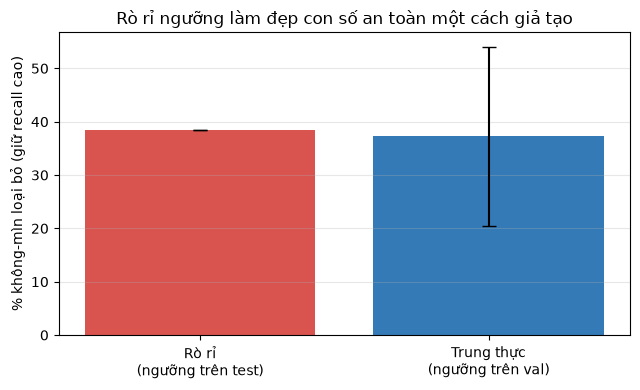

In [3]:
def leaky_operating_point(X, y, n_splits=5, n_repeats=4):
    elim = []
    for rep in range(n_repeats):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE+rep)
        for tr, te in skf.split(X, y):
            Xtr, Xte, ytr, yte = X[tr], X[te], y[tr], y[te]
            s = StandardScaler().fit(Xtr); Xtr2, Xte2 = s.transform(Xtr), s.transform(Xte)
            mdl = make_model().fit(Xtr2, ytr)
            p_te = mdl.predict_proba(Xte2)[:, 1]
            thr = thr_full_recall(yte, p_te)          # RÒ RỈ: chọn trên chính test
            tn, fp, fn, tp = confusion_matrix(yte, (p_te>=thr).astype(int), labels=[0,1]).ravel()
            elim.append(tn/(tn+fp) if (tn+fp)>0 else np.nan)
    return np.array(elim)

elim_leaky = leaky_operating_point(X, y)
print("BẢN RÒ RỈ  (chọn ngưỡng trên test):")
print(f"  Recall=100%% (theo định nghĩa, luôn đạt) | %% loại bỏ: {np.nanmean(elim_leaky)*100:.1f}%  <- LẠC QUAN GIẢ")
print("BẢN TRUNG THỰC (chọn trên val, đo trên test):")
print(f"  Recall thực: {np.nanmean(recs)*100:.1f}%  | %% loại bỏ: {np.nanmean(elim)*100:.1f}%")
print(f"\n  Chênh %% loại-bỏ do rò rỉ: {(np.nanmean(elim_leaky)-np.nanmean(elim))*100:+.1f} điểm (ảo)")

fig, ax = plt.subplots(figsize=(6.5,4))
ax.bar(["Rò rỉ\n(ngưỡng trên test)","Trung thực\n(ngưỡng trên val)"],
       [np.nanmean(elim_leaky)*100, np.nanmean(elim)*100],
       yerr=[0, np.nanstd(elim)*100], capsize=5, color=["#d9534f","#337ab7"])
ax.set_ylabel("% không-mìn loại bỏ (giữ recall cao)")
ax.set_title("Rò rỉ ngưỡng làm đẹp con số an toàn một cách giả tạo")
ax.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig("../result/figures/06_leak_vs_honest.png", bbox_inches="tight"); plt.show()

## 5. Đường cong Precision–Recall (từ xác suất out-of-fold — ổn định)

Dùng xác suất out-of-fold (mỗi mẫu được dự đoán khi nằm ngoài train) thay cho một split, cho đường PR ổn định hơn.

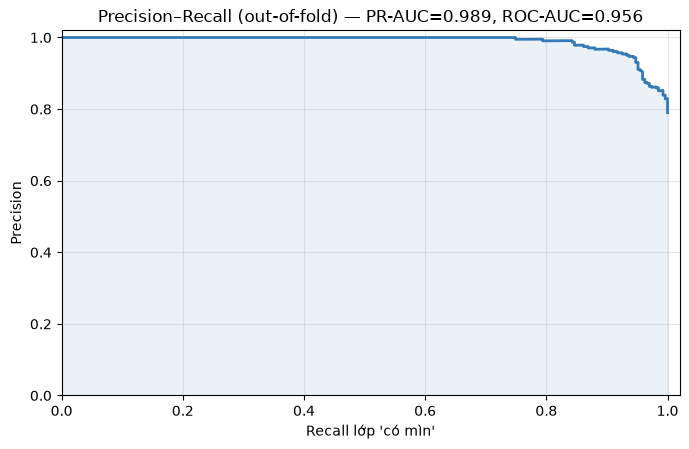

PR-AUC (oof) = 0.989 | ROC-AUC (oof) = 0.956


In [4]:
mask = ~np.isnan(oof_p)
prec, rec, thr = precision_recall_curve(y[mask], oof_p[mask])
ap = average_precision_score(y[mask], oof_p[mask])
auc = roc_auc_score(y[mask], oof_p[mask])
fig, ax = plt.subplots(figsize=(7,4.6))
ax.plot(rec, prec, color="#337ab7", lw=2); ax.fill_between(rec, prec, alpha=0.1, color="#337ab7")
ax.set_xlabel("Recall lớp 'có mìn'"); ax.set_ylabel("Precision")
ax.set_title(f"Precision–Recall (out-of-fold) — PR-AUC={ap:.3f}, ROC-AUC={auc:.3f}")
ax.grid(alpha=0.3); ax.set_xlim(0,1.02); ax.set_ylim(0,1.02)
plt.tight_layout(); plt.savefig("../result/figures/06_pr_curve.png", bbox_inches="tight"); plt.show()
print(f"PR-AUC (oof) = {ap:.3f} | ROC-AUC (oof) = {auc:.3f}")

## 6. Ma trận chi phí — ngưỡng tối ưu (chọn trên val, đo trên test)

Gán chi phí: bỏ sót 1 mìn = `COST_FN`, đào nhầm = `COST_FP`. Với mỗi fold, chọn ngưỡng tối thiểu hóa chi phí **trên validation**, rồi tính chi phí thực **trên test**. Vì FN đắt gấp bội, ngưỡng tối ưu dịch xuống rất thấp — mô hình "đa nghi", thà báo động giả còn hơn bỏ sót.

Ngưỡng tối ưu chi phí (chọn trên val): 0.11 ± 0.02
Chi phí trung bình trên test/fold: 610


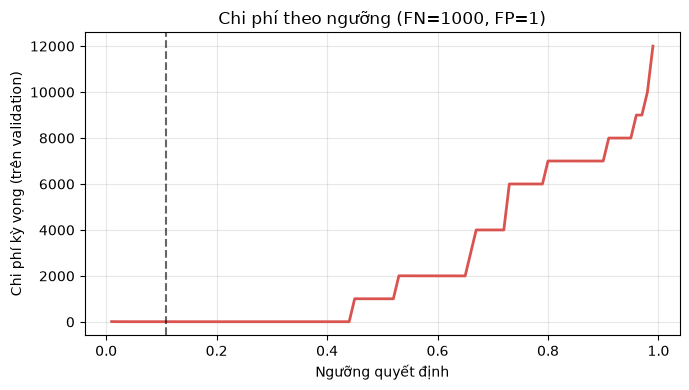

In [5]:
COST_FN, COST_FP = 1000, 1

def cost_of(y_true, p, thr):
    tn, fp, fn, tp = confusion_matrix(y_true, (p>=thr).astype(int), labels=[0,1]).ravel()
    return fn*COST_FN + fp*COST_FP, fn, fp

grid = np.linspace(0.01, 0.99, 99)
test_costs, thr_used = [], []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for tr, te in skf.split(X, y):
    Xtr, Xte, ytr, yte = X[tr], X[te], y[tr], y[te]
    Xt, Xv, yt, yv = train_test_split(Xtr, ytr, test_size=0.25, stratify=ytr, random_state=RANDOM_STATE)
    s = StandardScaler().fit(Xt); Xt2, Xv2, Xte2 = s.transform(Xt), s.transform(Xv), s.transform(Xte)
    mdl = make_model().fit(Xt2, yt)
    pv, pte = mdl.predict_proba(Xv2)[:,1], mdl.predict_proba(Xte2)[:,1]
    t_opt = grid[np.argmin([cost_of(yv, pv, t)[0] for t in grid])]   # tối ưu trên VAL
    c, fn, fp = cost_of(yte, pte, t_opt)
    test_costs.append(c); thr_used.append(t_opt)

print(f"Ngưỡng tối ưu chi phí (chọn trên val): {np.mean(thr_used):.2f} ± {np.std(thr_used):.2f}")
print(f"Chi phí trung bình trên test/fold: {np.mean(test_costs):.0f}")

# minh hoa duong chi phi tren 1 fold val
plt.figure(figsize=(7,4))
plt.plot(grid, [cost_of(yv, pv, t)[0] for t in grid], color="#d9534f", lw=2)
plt.axvline(np.mean(thr_used), ls="--", color="black", alpha=.6)
plt.xlabel("Ngưỡng quyết định"); plt.ylabel("Chi phí kỳ vọng (trên validation)")
plt.title(f"Chi phí theo ngưỡng (FN={COST_FN}, FP={COST_FP})")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("../result/figures/06_cost_threshold.png", bbox_inches="tight"); plt.show()

## 7. Phân tích theo loại đất — bằng RECALL (không phải accuracy)

Với bài toán mìn, câu hỏi thực địa là *loại đất nào hay BỎ SÓT mìn nhất*. Dùng recall của lớp "có mìn" trên dự đoán out-of-fold (ổn định hơn một split). Kiểm tra bảng mã loại đất khớp mô tả dữ liệu (S chuẩn hóa 0.0–1.0 cho 6 loại).

 Loại đất  Số mìn  Recall (%)
 Ẩm & mùn      46        91.3
Khô & cát      47        91.5
Khô & sét      44        95.5
 Ẩm & cát      45        95.6
Khô & mùn      39        97.4
 Ẩm & sét      46        97.8


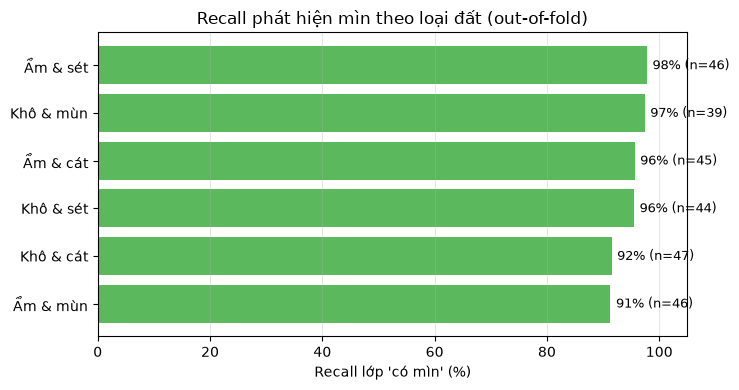

In [6]:
soil_names = {0.0:"Khô & cát", 0.2:"Khô & mùn", 0.4:"Khô & sét",
              0.6:"Ẩm & cát", 0.8:"Ẩm & mùn", 1.0:"Ẩm & sét"}
S = X[:, 2]
oof_pred = (oof_p >= 0.5).astype(float)
rows = []
for sv in sorted(np.unique(S)):
    m = mask & (S == sv) & (y == 1)          # chỉ các mẫu CÓ MÌN của loại đất này
    if m.sum() > 0:
        recall = (oof_pred[m] == 1).mean()
        rows.append({"Loại đất": soil_names.get(round(sv,1), f"S={sv:.1f}"),
                     "Số mìn": int(m.sum()),
                     "Recall (%)": round(recall*100, 1)})
soil_tbl = pd.DataFrame(rows).sort_values("Recall (%)").reset_index(drop=True)
print(soil_tbl.to_string(index=False))

fig, ax = plt.subplots(figsize=(7.5,4))
colors = ["#d9534f" if r < 85 else "#5cb85c" for r in soil_tbl["Recall (%)"]]
ax.barh(soil_tbl["Loại đất"], soil_tbl["Recall (%)"], color=colors)
ax.set_xlabel("Recall lớp 'có mìn' (%)"); ax.set_xlim(0, 105)
ax.set_title("Recall phát hiện mìn theo loại đất (out-of-fold)")
for i,(r,n) in enumerate(zip(soil_tbl["Recall (%)"], soil_tbl["Số mìn"])):
    ax.text(r+1, i, f"{r:.0f}% (n={n})", va="center", fontsize=9)
ax.grid(axis="x", alpha=0.3); plt.tight_layout()
plt.savefig("../result/figures/06_recall_theo_dat.png", bbox_inches="tight"); plt.show()

## Tổng kết Giai đoạn 6

- **Vì sao accuracy sai** trong bài toán an toàn: hai kiểu lỗi không ngang nhau; dùng PR + recall thay accuracy/ROC.
- **Sửa rò rỉ ngưỡng:** chọn ngưỡng trên **validation**, đánh giá trên **test tách biệt**, lặp qua CV — nhất quán với toàn đồ án.
- **Thông điệp an toàn mạnh:** ngưỡng đạt recall=100% trên validation **không luôn giữ 100% trên dữ liệu mới** — một tỷ lệ fold vẫn bỏ sót mìn. Không thể đảm bảo tuyệt đối không bỏ sót chỉ bằng một ngưỡng cố định; cần biên an toàn và quy trình rà thủ công song song.
- **Đối chiếu rò rỉ vs trung thực:** cho thấy chọn ngưỡng trên test làm đẹp con số an toàn một cách giả tạo (đúng lỗi bài báo).
- **Ma trận chi phí:** mô hình hóa hậu quả bất đối xứng; FN đắt gấp bội đẩy ngưỡng xuống thấp.
- **Recall theo loại đất:** chỉ ra loại đất nào hay bỏ sót mìn — phục vụ vận hành thực địa.

**Cho báo cáo:** hệ thống là công cụ **hỗ trợ ưu tiên/giảm công đào ở điểm an toàn**, không thay thế quy trình rà phá; và phải nêu rõ giới hạn: không một ngưỡng nào đảm bảo 0% bỏ sót trên dữ liệu chưa thấy.